# VNIndex Volatility Analysis

Multi-metric volatility study on the VN-Index:
- **Historical Volatility** (multiple windows)
- **Yang-Zhang** (OHLC estimator — lowest bias)
- **Parkinson** (high-low estimator)
- **Garman-Klass** (open-high-low-close estimator)
- **EWMA** (exponentially weighted, λ-tunable)
- **ATR-based** normalised volatility
- **Williams VIX Fix** (synthetic fear index)
- **Volatility regime** classification (High / Normal / Low)
- **Term-structure** surface (rolling vol across multiple horizons)


In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import talib
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#333355',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'legend.facecolor': '#2a2a4e',
    'legend.labelcolor':'white',
})

ANNUALISE = 252   # trading days per year
SYMBOL    = 'VNINDEX'
print('Libraries loaded')


Libraries loaded


## 1. Load Data

In [13]:
import os
from deltalake import DeltaTable

REMOTE_HOST = "https://minio.phuchuynh.xyz"
LOCAL_FILE  = "stocks_data_latest.h5"

if os.path.exists(LOCAL_FILE):
    print(f"Loading from local HDF5: {LOCAL_FILE}")
    with pd.HDFStore(LOCAL_FILE, mode='r') as store:
        df_all = store['stocks']
else:
    print("Loading from Delta Lake …")
    storage_options = {
        "AWS_ACCESS_KEY_ID":        "CzOwnLkEDXQy951AOqes",
        "AWS_SECRET_ACCESS_KEY":    "fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S",
        "AWS_ENDPOINT_URL":         REMOTE_HOST,
        "AWS_ALLOW_HTTP":           "true",
        "AWS_EC2_METADATA_DISABLED":"true",
        "AWS_REGION":               "us-east-1",
        "aws_conditional_put":      "etag",
    }
    dt   = DeltaTable("s3://delta-table-storage/stocks", storage_options=storage_options)
    now  = pd.Timestamp.now()
    df_all = dt.to_pandas(
        filters=[("date", ">=", now - pd.DateOffset(years=5)),
                 ("symbol", "=", SYMBOL)],
        columns=["symbol", "date", "close", "open", "high", "low", "volume"],
    )
    df_all = df_all.set_index(["date", "symbol"]).unstack(level=1)

# Extract VNINDEX OHLCV as a plain DataFrame
vn = pd.DataFrame({
    'open':   df_all['open'][SYMBOL],
    'high':   df_all['high'][SYMBOL],
    'low':    df_all['low'][SYMBOL],
    'close':  df_all['close'][SYMBOL],
    'volume': df_all['volume'][SYMBOL],
}).dropna()

vn.index = pd.to_datetime(vn.index)
vn = vn.sort_index()

print(f"Loaded {len(vn):,} bars  |  {vn.index[0].date()} → {vn.index[-1].date()}")
vn.tail(3)


Loading from local HDF5: stocks_data_latest.h5
Loaded 2,500 bars  |  2016-04-04 → 2026-04-03


,open,high,low,close,volume
date,,,,,
2026-04-01,1713.920044,1715.209961,1700.180054,1705.739990,905114368.0
2026-04-02,1706.150024,1706.150024,1684.469971,1695.130005,823926592.0
2026-04-03,1700.140015,1713.949951,1679.790039,1684.089966,726054464.0


## 2. Log Returns & Basic Stats

Daily log-return stats (annualised):
  Mean  : 11.18% p.a.
  Std   : 18.79% p.a.
  Skew  : -1.043
  Kurt  : 5.495


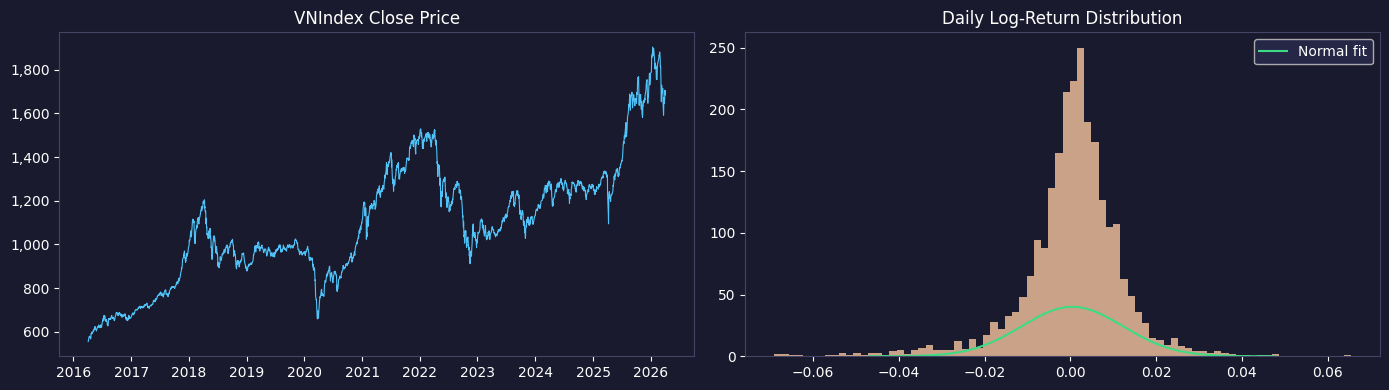

In [14]:
vn['log_ret'] = np.log(vn['close'] / vn['close'].shift(1))

print(f"Daily log-return stats (annualised):")
print(f"  Mean  : {vn['log_ret'].mean() * ANNUALISE * 100:.2f}% p.a.")
print(f"  Std   : {vn['log_ret'].std() * np.sqrt(ANNUALISE) * 100:.2f}% p.a.")
print(f"  Skew  : {vn['log_ret'].skew():.3f}")
print(f"  Kurt  : {vn['log_ret'].kurtosis():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax1, ax2 = axes

ax1.plot(vn.index, vn['close'], color='#4fc3f7', lw=0.8)
ax1.set_title('VNIndex Close Price', color='white')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2.hist(vn['log_ret'].dropna(), bins=80, color='#f7c59f', edgecolor='none', alpha=0.8)
mu, sigma = vn['log_ret'].mean(), vn['log_ret'].std()
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
ax2.plot(x, stats.norm.pdf(x, mu, sigma) * len(vn['log_ret']) * (x[1]-x[0]),
         color='#3ddc84', lw=1.5, label='Normal fit')
ax2.set_title('Daily Log-Return Distribution', color='white')
ax2.legend()

plt.tight_layout()
plt.show()


## 3. Volatility Estimators

In [15]:
def hist_vol(log_ret: pd.Series, window: int, annualise: int = ANNUALISE) -> pd.Series:
    """Close-to-close historical volatility (annualised)."""
    return log_ret.rolling(window).std() * np.sqrt(annualise)


def parkinson_vol(high: pd.Series, low: pd.Series, window: int,
                  annualise: int = ANNUALISE) -> pd.Series:
    """Parkinson (1980): uses high-low range only. ~5x more efficient than close-to-close."""
    k = 1.0 / (4.0 * np.log(2))
    hl2 = (np.log(high / low) ** 2)
    return np.sqrt(hl2.rolling(window).mean() * k * annualise)


def garman_klass_vol(open_: pd.Series, high: pd.Series, low: pd.Series,
                     close: pd.Series, window: int, annualise: int = ANNUALISE) -> pd.Series:
    """Garman-Klass (1980): OHLC estimator, corrects for overnight gaps."""
    log_hl = np.log(high / low) ** 2
    log_co = np.log(close / open_) ** 2
    gk = (0.5 * log_hl - (2 * np.log(2) - 1) * log_co).rolling(window).mean()
    return np.sqrt(gk * annualise)


def yang_zhang_vol(open_: pd.Series, high: pd.Series, low: pd.Series,
                   close: pd.Series, window: int, annualise: int = ANNUALISE) -> pd.Series:
    """Yang-Zhang (2000): minimum-variance unbiased OHLC estimator."""
    log_co = np.log(close / open_)
    log_oc = np.log(open_ / close.shift(1))
    rs     = (np.log(high / close) * np.log(high / open_)
              + np.log(low / close) * np.log(low / open_))
    n  = window
    k  = 0.34 / (1.34 + (n + 1) / (n - 1))
    yz_var = (log_oc.rolling(n).var()
              + k * log_co.rolling(n).var()
              + (1 - k) * rs.rolling(n).mean())
    return np.sqrt(yz_var.clip(lower=0) * annualise)


def ewma_vol(log_ret: pd.Series, lam: float = 0.94,
             annualise: int = ANNUALISE) -> pd.Series:
    """RiskMetrics EWMA volatility (lambda=0.94 is the standard daily decay)."""
    return log_ret.ewm(alpha=1 - lam, adjust=False).std() * np.sqrt(annualise)


def williams_vix_fix(close: pd.Series, low: pd.Series,
                     period: int = 22, mult: float = 2.0,
                     bbl: int = 20, lb: int = 50, ph: float = 0.85) -> pd.DataFrame:
    """Synthetic VIX using Williams VIX Fix formula."""
    highest_close = close.rolling(period).max()
    wvf           = (highest_close - low) / highest_close * 100.0
    mid           = wvf.rolling(bbl).mean()
    sdev          = wvf.rolling(bbl).std()
    upper_band    = mid + mult * sdev
    range_high    = wvf.rolling(lb).max() * ph
    return pd.DataFrame({'wvf': wvf, 'upper_band': upper_band, 'range_high': range_high})


print('Volatility estimators defined')


Volatility estimators defined


In [16]:
WINDOW = 20   # base window for rolling estimators

vn['hv_10']  = hist_vol(vn['log_ret'], 10)
vn['hv_20']  = hist_vol(vn['log_ret'], 20)
vn['hv_60']  = hist_vol(vn['log_ret'], 60)
vn['park']   = parkinson_vol(vn['high'], vn['low'], WINDOW)
vn['gk']     = garman_klass_vol(vn['open'], vn['high'], vn['low'], vn['close'], WINDOW)
vn['yz']     = yang_zhang_vol(vn['open'], vn['high'], vn['low'], vn['close'], WINDOW)
vn['ewma']   = ewma_vol(vn['log_ret'])
vn['atr_pct'] = (talib.ATR(vn['high'].values, vn['low'].values,
                            vn['close'].values, timeperiod=WINDOW)
                 / vn['close']) * np.sqrt(ANNUALISE)

wvf_df = williams_vix_fix(vn['close'], vn['low'])
vn['wvf']        = wvf_df['wvf']
vn['wvf_upper']  = wvf_df['upper_band']
vn['wvf_range']  = wvf_df['range_high']

print(f"Latest volatility readings (window={WINDOW}d):")
for col, label in [('hv_20','HV-20'), ('park','Parkinson'), ('gk','Garman-Klass'),
                   ('yz','Yang-Zhang'), ('ewma','EWMA'), ('atr_pct','ATR%')]:
    print(f"  {label:15s}: {vn[col].iloc[-1]*100:.2f}%")


Latest volatility readings (window=20d):
  HV-20          : 36.15%
  Parkinson      : 25.04%
  Garman-Klass   : 22.69%
  Yang-Zhang     : 27.77%
  EWMA           : 28.38%
  ATR%           : 35.96%


## 4. Volatility Comparison

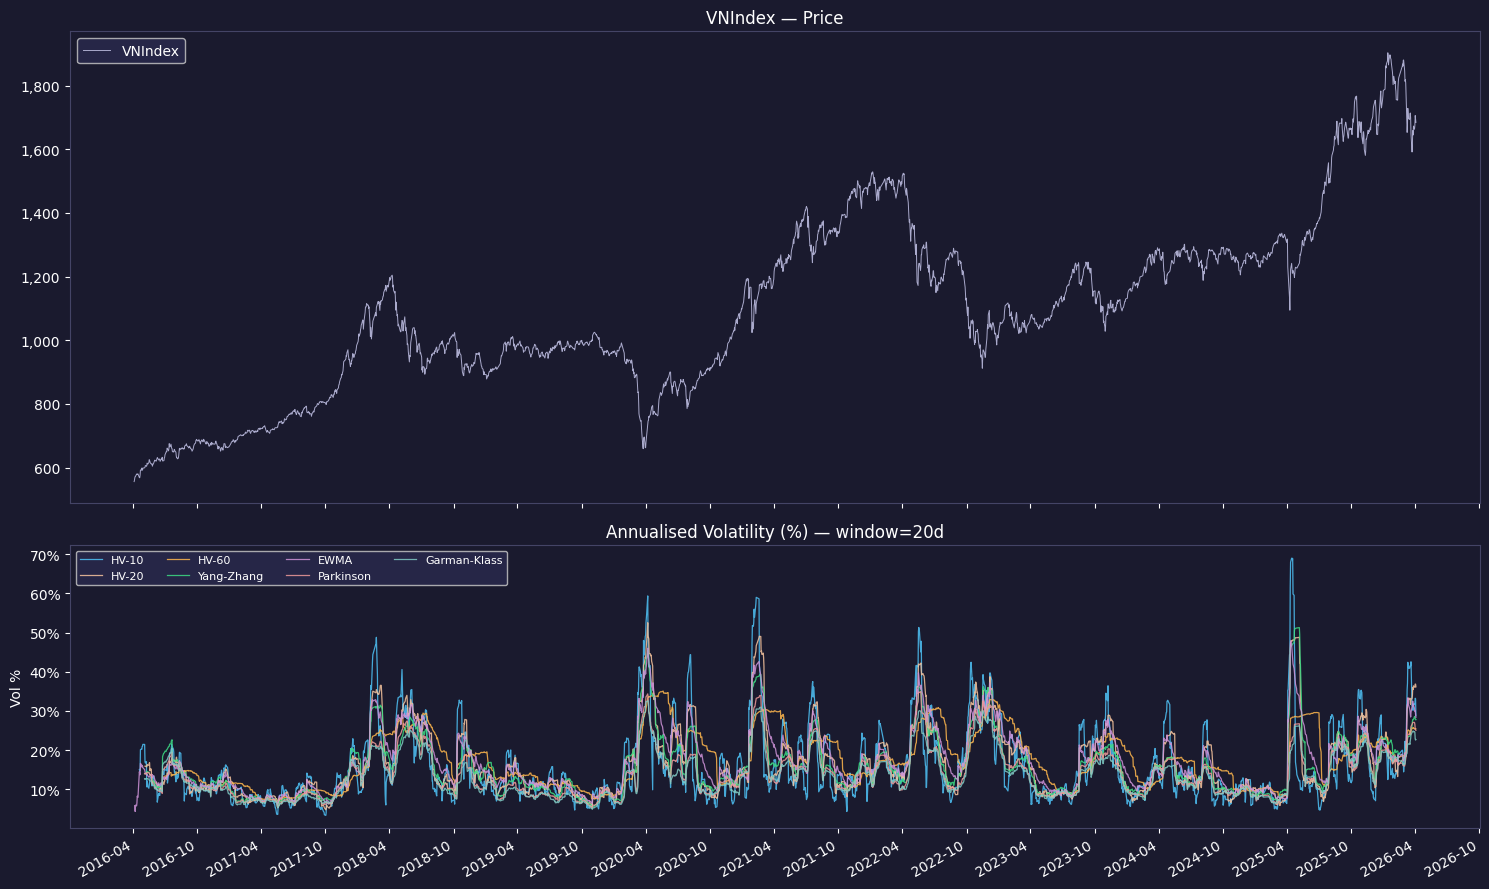

In [17]:
x = vn.index
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.06,
    row_heights=[2 / 3.2, 1.2 / 3.2],
    subplot_titles=('VNIndex — Price', f'Annualised Volatility (%) — window={WINDOW}d'),
)

fig.add_trace(
    go.Scatter(x=x, y=vn['close'], name='VNIndex', line=dict(color='#aaaacc', width=1)),
    row=1, col=1,
)

colors = {'HV-10': '#4fc3f7', 'HV-20': '#f7c59f', 'HV-60': '#ffb74d',
          'Yang-Zhang': '#3ddc84', 'EWMA': '#ce93d8', 'Parkinson': '#ef9a9a',
          'Garman-Klass': '#80cbc4'}
for (col, label), color in zip([
        ('hv_10', 'HV-10'), ('hv_20', 'HV-20'), ('hv_60', 'HV-60'),
        ('yz', 'Yang-Zhang'), ('ewma', 'EWMA'), ('park', 'Parkinson'), ('gk', 'Garman-Klass'),
    ], colors.values()):
    fig.add_trace(
        go.Scatter(x=x, y=vn[col] * 100, name=label, line=dict(color=color, width=1), opacity=0.85),
        row=2, col=1,
    )

fig.update_layout(
    template='plotly_dark',
    paper_bgcolor='#1a1a2e',
    plot_bgcolor='#1a1a2e',
    height=900,
    width=1150,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=-0.22, x=0, xanchor='left', font=dict(size=9)),
    margin=dict(t=60, b=100, l=60, r=40),
)
fig.update_yaxes(tickformat=',.0f', row=1, col=1)
fig.update_yaxes(title_text='Vol %', ticksuffix='%', tickformat='.0f', row=2, col=1)
fig.update_xaxes(tickformat='%Y-%m', tickangle=-30, dtick='M6', row=2, col=1)

fig.show(config={'scrollZoom': True, 'displayModeBar': True})


## 5. Volatility Regime Classification

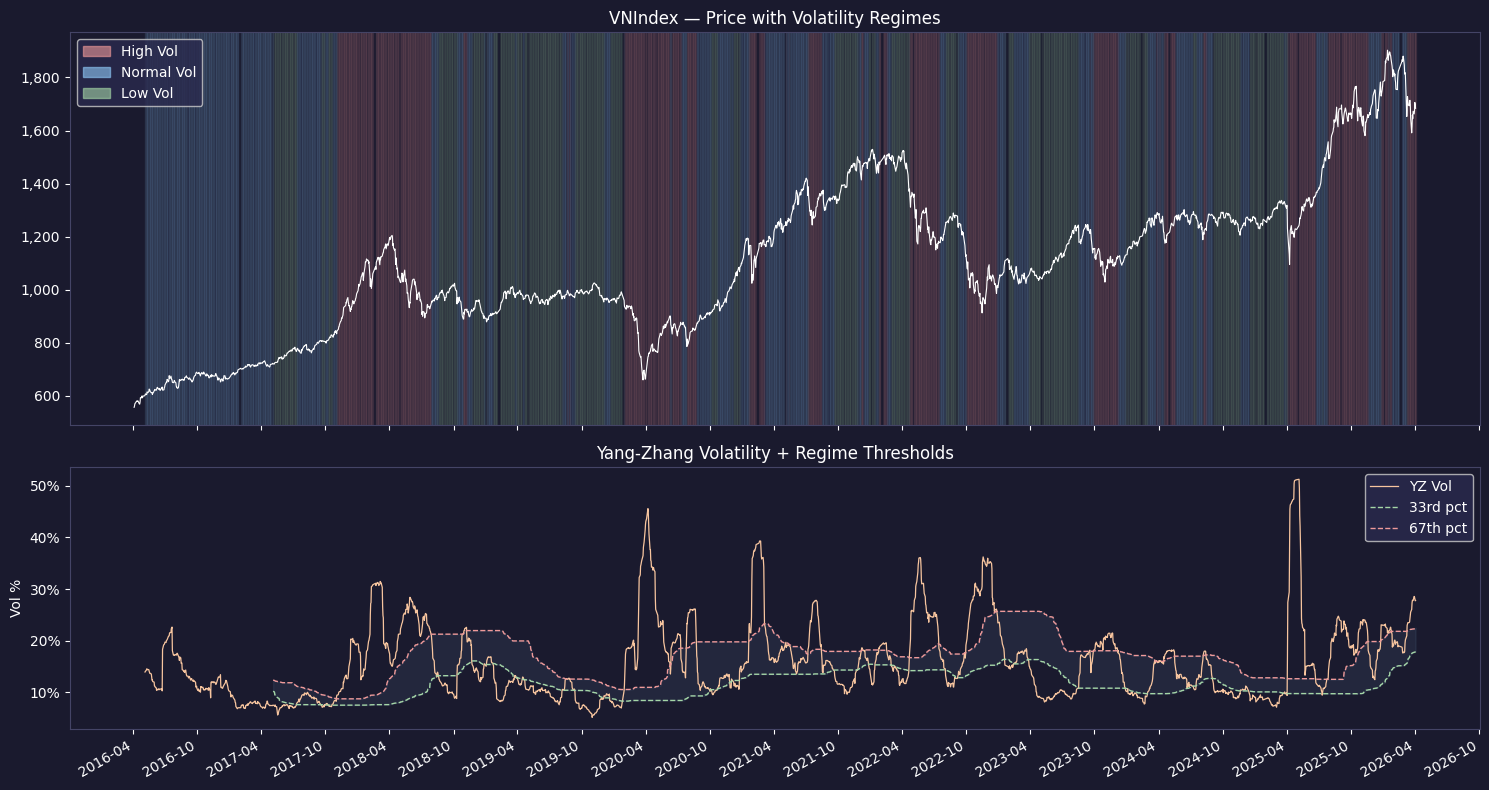


Regime distribution:
  Normal  :  947 days (38.2%)
           avg vol = 13.73%,  median = 13.56%
  High    :  769 days (31.0%)
           avg vol = 23.76%,  median = 22.42%
  Low     :  764 days (30.8%)
           avg vol = 10.01%,  median = 9.85%


In [18]:
# Use Yang-Zhang as the primary vol series (lowest bias)
vol_series = vn['yz'].dropna()

# Percentile-based thresholds (rolling 252-day lookback to avoid lookahead)
roll_lo = vol_series.rolling(252).quantile(0.33)
roll_hi = vol_series.rolling(252).quantile(0.67)

regime = pd.Series('Normal', index=vol_series.index)
regime[vol_series < roll_lo] = 'Low'
regime[vol_series > roll_hi] = 'High'

vn['vol_regime'] = regime

# ── Chart ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                                gridspec_kw={'height_ratios': [1.5, 1]})

# Price with regime shading
for date, reg in regime.items():
    color = {'High': '#ef9a9a', 'Low': '#a5d6a7', 'Normal': '#90caf9'}.get(reg, 'grey')
    ax1.axvspan(date, date + pd.Timedelta(days=1), color=color, alpha=0.06)
ax1.plot(vn.index, vn['close'], color='white', lw=0.8)
ax1.set_title('VNIndex — Price with Volatility Regimes', color='white')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
# Legend patches
from matplotlib.patches import Patch
ax1.legend(handles=[Patch(color='#ef9a9a', alpha=0.6, label='High Vol'),
                    Patch(color='#90caf9', alpha=0.6, label='Normal Vol'),
                    Patch(color='#a5d6a7', alpha=0.6, label='Low Vol')])

# Vol with thresholds
ax2.plot(vol_series.index, vol_series * 100, color='#f7c59f', lw=0.9, label='YZ Vol')
ax2.plot(roll_lo.index, roll_lo * 100, color='#a5d6a7', lw=1, ls='--', label='33rd pct')
ax2.plot(roll_hi.index, roll_hi * 100, color='#ef9a9a', lw=1, ls='--', label='67th pct')
ax2.fill_between(vol_series.index, roll_lo * 100, roll_hi * 100, alpha=0.08, color='#90caf9')
ax2.set_title('Yang-Zhang Volatility + Regime Thresholds', color='white')
ax2.set_ylabel('Vol %')
ax2.legend()
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

# Distribution per regime
counts = regime.value_counts()
print("\nRegime distribution:")
for r, n in counts.items():
    print(f"  {r:8s}: {n:4d} days ({n/len(regime)*100:.1f}%)")
    sub = vol_series[regime == r]
    print(f"           avg vol = {sub.mean()*100:.2f}%,  median = {sub.median()*100:.2f}%")


## 6. Volatility Term Structure

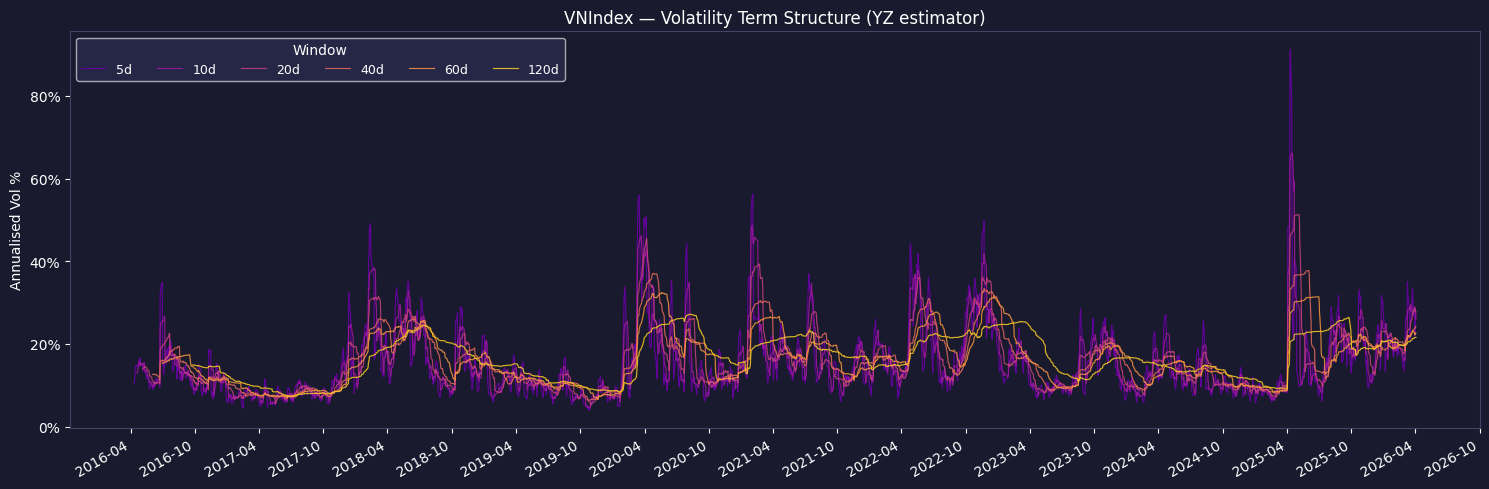


Latest term-structure snapshot:
    5d: 26.97%
   10d: 25.90%
   20d: 27.77%
   40d: 24.23%
   60d: 22.59%
  120d: 21.56%


In [19]:
# Rolling Yang-Zhang vol across multiple horizons
windows = [5, 10, 20, 40, 60, 120]
colors_ts = plt.cm.plasma(np.linspace(0.2, 0.9, len(windows)))

fig, ax = plt.subplots(figsize=(15, 5))

for w, c in zip(windows, colors_ts):
    v = yang_zhang_vol(vn['open'], vn['high'], vn['low'], vn['close'], w)
    ax.plot(v.index, v * 100, lw=0.85, label=f'{w}d', color=c, alpha=0.85)

ax.set_title('VNIndex — Volatility Term Structure (YZ estimator)', color='white', fontsize=12)
ax.set_ylabel('Annualised Vol %')
ax.legend(ncol=6, title='Window', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Latest snapshot — term structure curve
print("\nLatest term-structure snapshot:")
for w in windows:
    v = yang_zhang_vol(vn['open'], vn['high'], vn['low'], vn['close'], w)
    print(f"  {w:3d}d: {v.iloc[-1]*100:.2f}%")


## 7. Williams VIX Fix (Synthetic Fear Index)

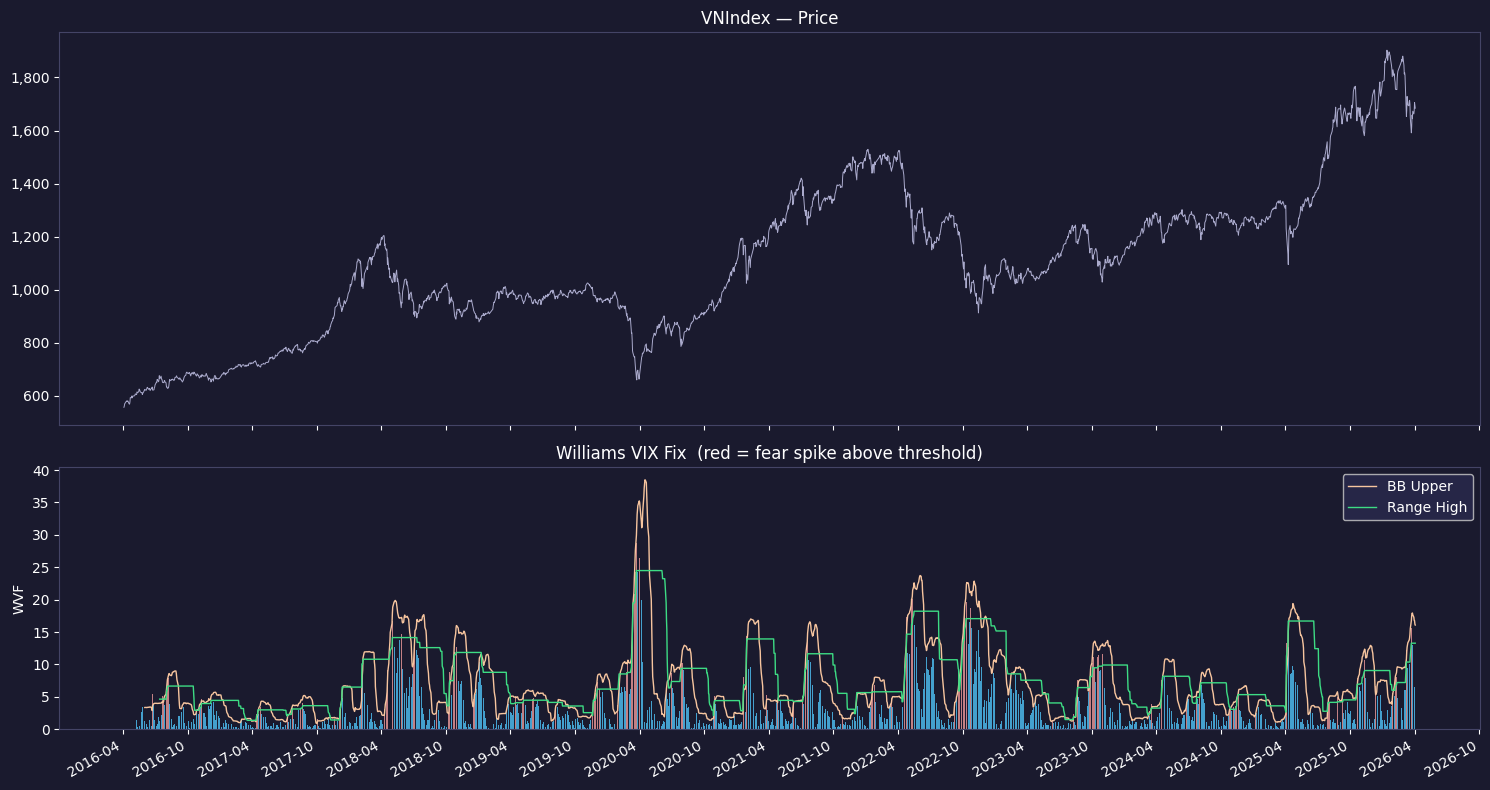

Fear-spike frequency: 15.1% of all days


In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                                gridspec_kw={'height_ratios': [1.5, 1]})

# Price
ax1.plot(vn.index, vn['close'], color='#aaaacc', lw=0.7)
ax1.set_title('VNIndex — Price', color='white')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# WVF bars coloured by threshold breach
wvf_color = np.where(
    (vn['wvf'] >= vn['wvf_upper']) | (vn['wvf'] >= vn['wvf_range']),
    '#ef9a9a',   # fear spike
    '#4fc3f7',   # normal
)
ax2.bar(vn.index, vn['wvf'], color=wvf_color, width=1, alpha=0.8)
ax2.plot(vn.index, vn['wvf_upper'], color='#f7c59f', lw=1,   label='BB Upper')
ax2.plot(vn.index, vn['wvf_range'], color='#3ddc84', lw=1,   label='Range High')
ax2.set_title('Williams VIX Fix  (red = fear spike above threshold)', color='white')
ax2.set_ylabel('WVF')
ax2.legend()

for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

fear_pct = ((vn['wvf'] >= vn['wvf_upper']) | (vn['wvf'] >= vn['wvf_range'])).mean()
print(f"Fear-spike frequency: {fear_pct*100:.1f}% of all days")


## 8. Monthly Volatility Heatmap

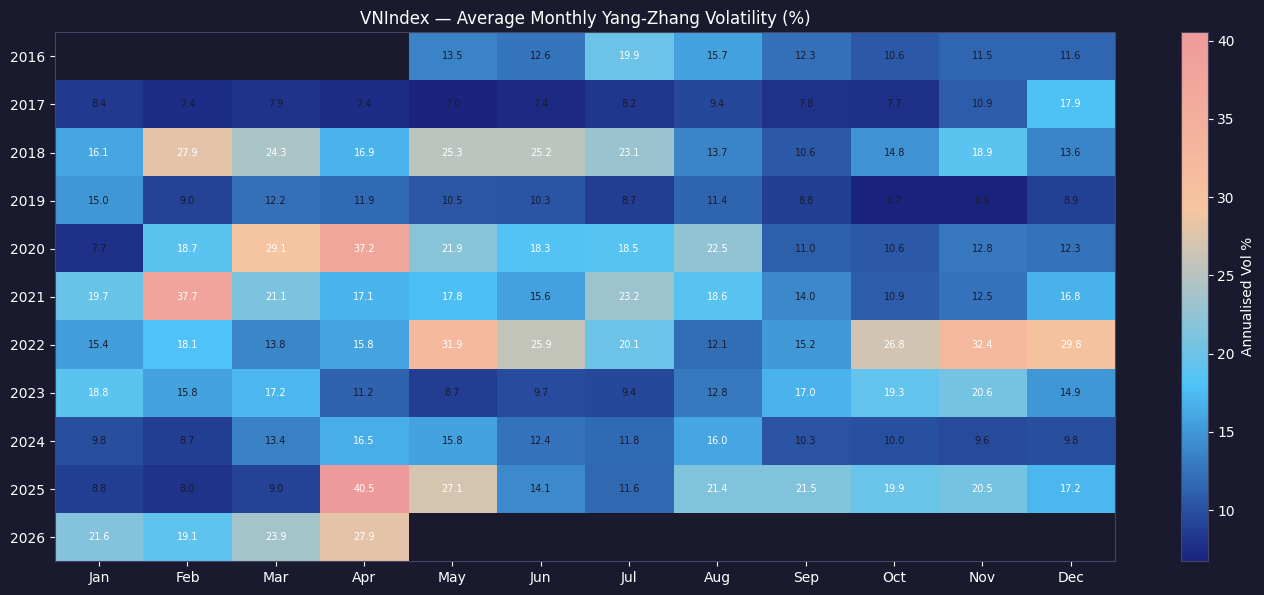

In [21]:
# Pivot: rows = year, columns = month, values = avg monthly YZ vol
vol_monthly = vn['yz'].copy()
vol_monthly.index = pd.to_datetime(vol_monthly.index)
pivot = (vol_monthly
         .groupby([vol_monthly.index.year, vol_monthly.index.month])
         .mean()
         .unstack(level=1) * 100)
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot.columns)]

fig, ax = plt.subplots(figsize=(14, max(4, len(pivot) * 0.55)))
cmap = LinearSegmentedColormap.from_list('vol', ['#1a237e', '#4fc3f7', '#f7c59f', '#ef9a9a'])
im = ax.imshow(pivot.values, aspect='auto', cmap=cmap)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, color='white')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index.astype(str), color='white')
ax.set_title('VNIndex — Average Monthly Yang-Zhang Volatility (%)', color='white', fontsize=12)
plt.colorbar(im, ax=ax, label='Annualised Vol %')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.iloc[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                    fontsize=7, color='white' if v > pivot.values[~np.isnan(pivot.values)].mean() else '#1a1a2e')

plt.tight_layout()
plt.show()


## 9. Summary Statistics

In [22]:
latest = vn.iloc[-1]
percentile_rank = lambda s: (s < s.iloc[-1]).mean() * 100

summary = pd.DataFrame({
    'Current (%)': {
        'HV-10':        vn['hv_10'].iloc[-1] * 100,
        'HV-20':        vn['hv_20'].iloc[-1] * 100,
        'HV-60':        vn['hv_60'].iloc[-1] * 100,
        'Parkinson':    vn['park'].iloc[-1] * 100,
        'Garman-Klass': vn['gk'].iloc[-1] * 100,
        'Yang-Zhang':   vn['yz'].iloc[-1] * 100,
        'EWMA':         vn['ewma'].iloc[-1] * 100,
        'ATR %':        vn['atr_pct'].iloc[-1] * 100,
    },
    '1Y Mean (%)': {
        'HV-10':        vn['hv_10'].tail(252).mean() * 100,
        'HV-20':        vn['hv_20'].tail(252).mean() * 100,
        'HV-60':        vn['hv_60'].tail(252).mean() * 100,
        'Parkinson':    vn['park'].tail(252).mean() * 100,
        'Garman-Klass': vn['gk'].tail(252).mean() * 100,
        'Yang-Zhang':   vn['yz'].tail(252).mean() * 100,
        'EWMA':         vn['ewma'].tail(252).mean() * 100,
        'ATR %':        vn['atr_pct'].tail(252).mean() * 100,
    },
    'Pctile Rank': {
        'HV-10':        percentile_rank(vn['hv_10'].dropna()),
        'HV-20':        percentile_rank(vn['hv_20'].dropna()),
        'HV-60':        percentile_rank(vn['hv_60'].dropna()),
        'Parkinson':    percentile_rank(vn['park'].dropna()),
        'Garman-Klass': percentile_rank(vn['gk'].dropna()),
        'Yang-Zhang':   percentile_rank(vn['yz'].dropna()),
        'EWMA':         percentile_rank(vn['ewma'].dropna()),
        'ATR %':        percentile_rank(vn['atr_pct'].dropna()),
    },
    'Regime': {k: vn['vol_regime'].iloc[-1] if k == 'Yang-Zhang' else '-'
               for k in ['HV-10','HV-20','HV-60','Parkinson','Garman-Klass','Yang-Zhang','EWMA','ATR %']},
}).round(2)

print(f"VNIndex Volatility Dashboard  —  as of {vn.index[-1].date()}")
print(f"Close: {vn['close'].iloc[-1]:,.2f}\n")
display(summary)


VNIndex Volatility Dashboard  —  as of 2026-04-03
Close: 1,684.09



,Current (%),1Y Mean (%),Pctile Rank,Regime
HV-10,28.81,20.63,89.24,-
HV-20,36.15,21.39,96.57,-
HV-60,25.41,21.66,84.51,-
Parkinson,25.04,17.93,92.95,-
Garman-Klass,22.69,17.51,91.94,-
Yang-Zhang,27.77,21.41,93.06,High
EWMA,28.38,22.03,89.67,-
ATR %,35.96,27.08,90.32,-
